RQ6: Which countries receive the most positive, neutral or negative sentiment in German media coverage and how does this sentiment vary between Tagesschau and ZDF?

Top countries used:
country
Germany           13078
Russia             1919
Ukraine            1708
United States      1684
Israel             1326
France              865
China               679
United Kingdom      606
Gaza Strip          502
Belgium             456
Italy               443
Austria             407
Name: count, dtype: int64


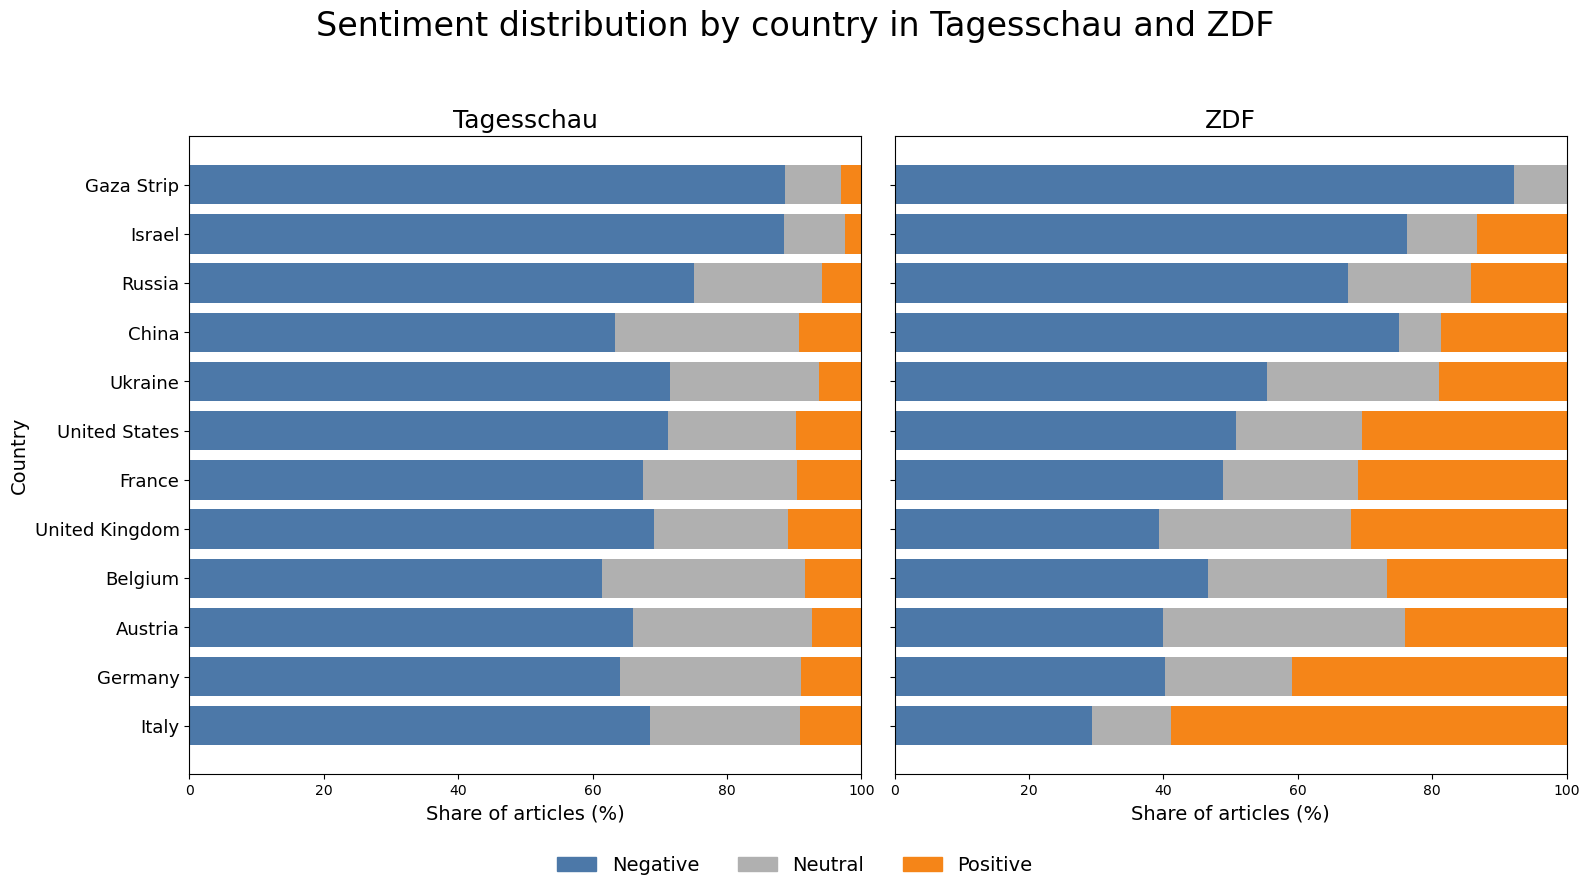

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

path = Path("locations_added.csv")
df = pd.read_csv(path)

def first_tone(x):
    try:
        return float(str(x).split(",")[0])
    except Exception:
        return np.nan

df["tone"] = df["V2Tone"].map(first_tone)

df = df[df["SourceCommonName"].isin(["tagesschau.de", "zdf.de"])].copy()

df["outlet"] = df["SourceCommonName"].replace({
    "tagesschau.de": "Tagesschau",
    "zdf.de": "ZDF"
})

def extract_first_location_name(loc_string):
    try:
        first_loc = str(loc_string).split(";")[0]
        parts = first_loc.split("#")
        if len(parts) > 1:
            return parts[1].strip()
        return np.nan
    except Exception:
        return np.nan

df["location_name"] = df["Locations"].apply(extract_first_location_name)

def extract_country(location_name):
    if pd.isna(location_name):
        return np.nan

    location_name = str(location_name).strip()

    if "," in location_name:
        return location_name.split(",")[-1].strip()

    return location_name

df["country"] = df["location_name"].apply(extract_country)

# remove missing tone/country
df = df.dropna(subset=["tone", "country"])

# remove broad/non-country labels
exclude_labels = {"World", "Europe", "Asia", "Middle East", "European Union"}
df = df[~df["country"].isin(exclude_labels)].copy()

# top countries
top_countries = df["country"].value_counts().head(12).index.tolist()
df_top = df[df["country"].isin(top_countries)].copy()

print("Top countries used:")
print(df_top["country"].value_counts())

def tone_category(x):
    if x < -1:
        return "Negative"
    elif x > 1:
        return "Positive"
    return "Neutral"

df_top["tone_category"] = df_top["tone"].apply(tone_category)

# shares
shares = (
    df_top.groupby(["country", "outlet", "tone_category"])
    .size()
    .unstack(fill_value=0)
)

for col in ["Negative", "Neutral", "Positive"]:
    if col not in shares.columns:
        shares[col] = 0

shares = shares[["Negative", "Neutral", "Positive"]]
shares = shares.div(shares.sum(axis=1), axis=0) * 100
shares = shares.reset_index()

# order countries
country_order = (
    shares.groupby("country")["Negative"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

shares["country"] = pd.Categorical(
    shares["country"],
    categories=country_order,
    ordered=True
)
shares = shares.sort_values("country")

# split data by outlet
tagesschau_data = (
    shares[shares["outlet"] == "Tagesschau"]
    .set_index("country")
    .reindex(country_order)
)

zdf_data = (
    shares[shares["outlet"] == "ZDF"]
    .set_index("country")
    .reindex(country_order)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 9), sharey=True)

colors = {
    "Negative": "#4C78A8",
    "Neutral": "#B0B0B0",
    "Positive": "#F58518"
}

for ax, data, title in zip(
    axes,
    [tagesschau_data, zdf_data],
    ["Tagesschau", "ZDF"]
):
    y = np.arange(len(country_order))

    ax.barh(y, data["Negative"], color=colors["Negative"])
    ax.barh(y, data["Neutral"], left=data["Negative"], color=colors["Neutral"])
    ax.barh(y, data["Positive"], left=data["Negative"] + data["Neutral"], color=colors["Positive"])

    ax.set_title(title, fontsize=18)
    ax.set_xlabel("Share of articles (%)", fontsize=14)
    ax.set_xlim(0, 100)
    ax.yaxis.grid(False)

axes[0].set_yticks(np.arange(len(country_order)))
axes[0].set_yticklabels(country_order, fontsize=13)
axes[0].set_ylabel("Country", fontsize=14)

fig.suptitle("Sentiment distribution by country in Tagesschau and ZDF", fontsize=24, y=0.98)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors["Negative"]),
    plt.Rectangle((0, 0), 1, 1, color=colors["Neutral"]),
    plt.Rectangle((0, 0), 1, 1, color=colors["Positive"])
]
labels = ["Negative", "Neutral", "Positive"]

fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, fontsize=14)

plt.tight_layout(rect=[0, 0.06, 1, 0.94])
plt.show()

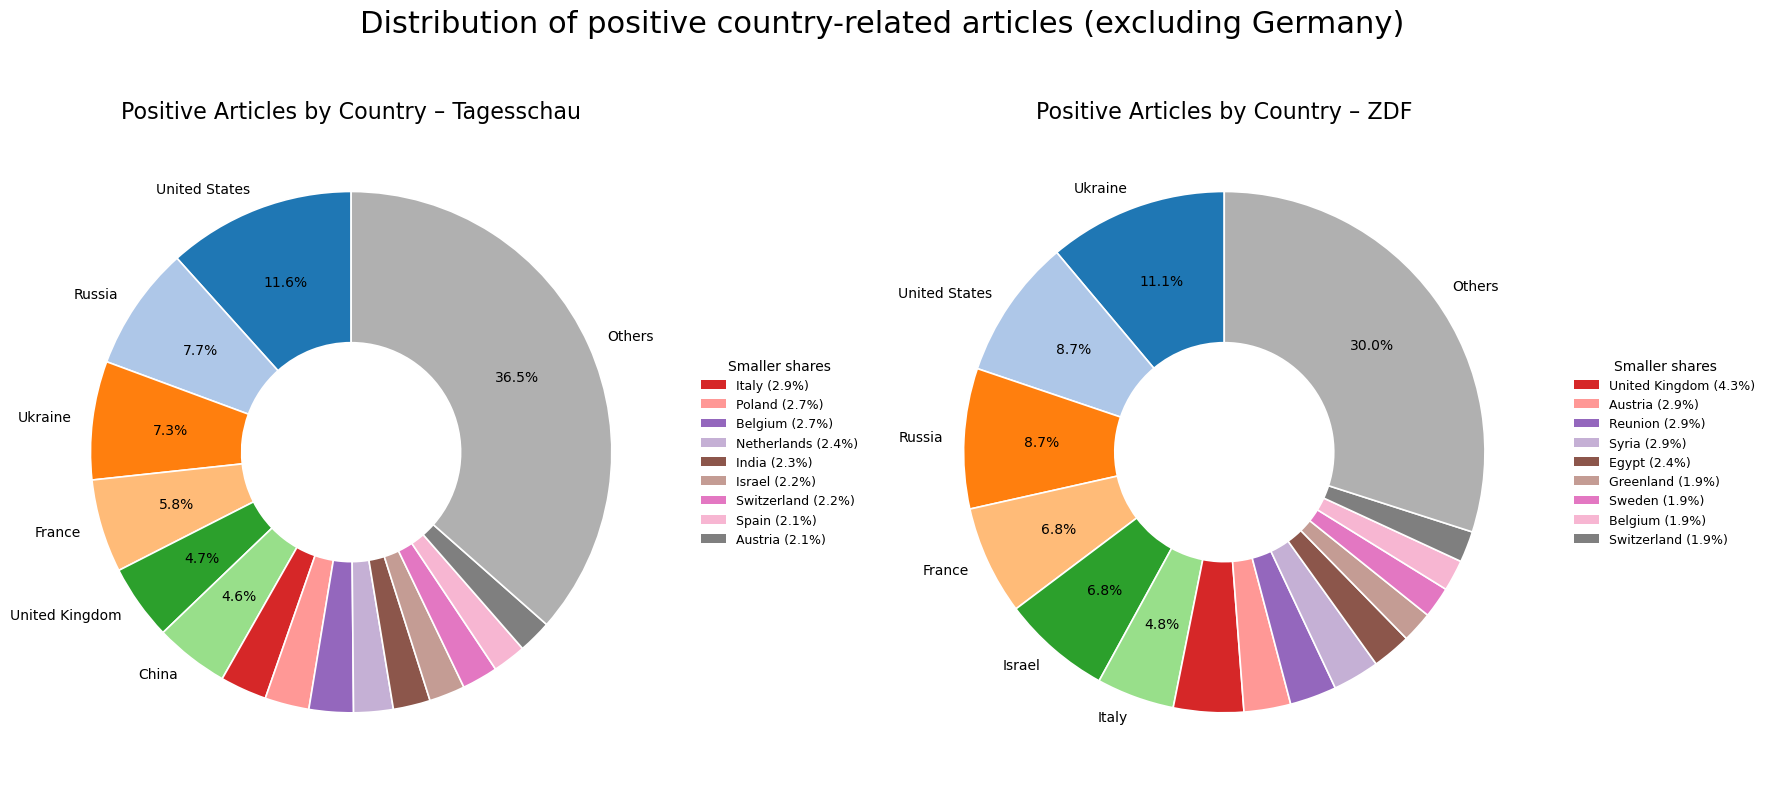

In [26]:
from matplotlib.patches import Patch

q6 = df[df['SourceCommonName'].isin(['tagesschau.de', 'zdf.de'])].copy()

q6['outlet'] = q6['SourceCommonName'].replace({
    'tagesschau.de': 'Tagesschau',
    'zdf.de': 'ZDF'
})

def first_tone(x):
    try:
        return float(str(x).split(',')[0])
    except Exception:
        return np.nan

q6['tone'] = q6['V2Tone'].map(first_tone)

# extract first location name
def extract_first_location_name(loc_string):
    try:
        first_loc = str(loc_string).split(';')[0]
        parts = first_loc.split('#')
        if len(parts) > 1:
            return parts[1].strip()
        return np.nan
    except Exception:
        return np.nan

q6['location_name'] = q6['Locations'].apply(extract_first_location_name)

# convert location to country
def extract_country(location_name):
    if pd.isna(location_name):
        return np.nan
    location_name = str(location_name).strip()
    if ',' in location_name:
        return location_name.split(',')[-1].strip()
    return location_name

q6['country'] = q6['location_name'].apply(extract_country)

# remove missing tone/country
q6 = q6.dropna(subset=['tone', 'country'])

# remove broad/non-country labels
exclude_labels = {'World', 'Europe', 'Asia', 'Middle East', 'European Union'}
q6 = q6[~q6['country'].isin(exclude_labels)].copy()

# keep only positive articles and exclude Germany
q6_pos = q6[(q6['tone'] > 1) & (q6['country'] != 'Germany')].copy()

# count positive articles by country and outlet
positive_counts = (
    q6_pos.groupby(['outlet', 'country'])
    .size()
    .reset_index(name='count')
)

def prepare_donut_data(data, outlet_name, top_n=15):
    outlet_data = data[data['outlet'] == outlet_name].sort_values('count', ascending=False).copy()
    top = outlet_data.head(top_n).copy()
    rest = outlet_data.iloc[top_n:]['count'].sum()

    if rest > 0:
        top = pd.concat([
            top,
            pd.DataFrame({'outlet': [outlet_name], 'country': ['Others'], 'count': [rest]})
        ], ignore_index=True)

    return top

def donut_with_clean_labels(ax, labels, values, title, direct_label_threshold=4.5):
    cmap = plt.get_cmap('tab20')
    colors = list(cmap.colors[:len(labels)])

    if 'Others' in labels:
        colors[labels.index('Others')] = '#b0b0b0'

    total = sum(values)
    percentages = [v / total * 100 for v in values]
    pie_labels = [lab if pct >= direct_label_threshold else '' for lab, pct in zip(labels, percentages)]

    wedges, texts, autotexts = ax.pie(
        values,
        labels=pie_labels,
        colors=colors,
        startangle=90,
        autopct=lambda p: f'{p:.1f}%' if p >= direct_label_threshold else '',
        pctdistance=0.70,
        labeldistance=1.08,
        wedgeprops=dict(width=0.58, edgecolor='white', linewidth=1.2)
    )

    for t in texts:
        t.set_fontsize(10)

    for t in autotexts:
        t.set_fontsize(10)
        t.set_color('black')

    ax.set_title(title, fontsize=16)
    ax.set_aspect('equal')

    small_items = [
        (lab, pct, col)
        for lab, pct, col in zip(labels, percentages, colors)
        if pct < direct_label_threshold
    ]

    if small_items:
        handles = [Patch(facecolor=col, edgecolor='none') for _, _, col in small_items]
        legend_labels = [f"{lab} ({pct:.1f}%)" for lab, pct, _ in small_items]

        ax.legend(
            handles,
            legend_labels,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            fontsize=9,
            title='Smaller shares',
            title_fontsize=10
        )

tagesschau_top = prepare_donut_data(positive_counts, 'Tagesschau', top_n=15)
zdf_top = prepare_donut_data(positive_counts, 'ZDF', top_n=15)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

donut_with_clean_labels(
    axes[0],
    tagesschau_top['country'].tolist(),
    tagesschau_top['count'].tolist(),
    'Positive Articles by Country – Tagesschau'
)

donut_with_clean_labels(
    axes[1],
    zdf_top['country'].tolist(),
    zdf_top['count'].tolist(),
    'Positive Articles by Country – ZDF'
)

fig.suptitle(
    'Distribution of positive country-related articles (excluding Germany)',
    fontsize=22,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

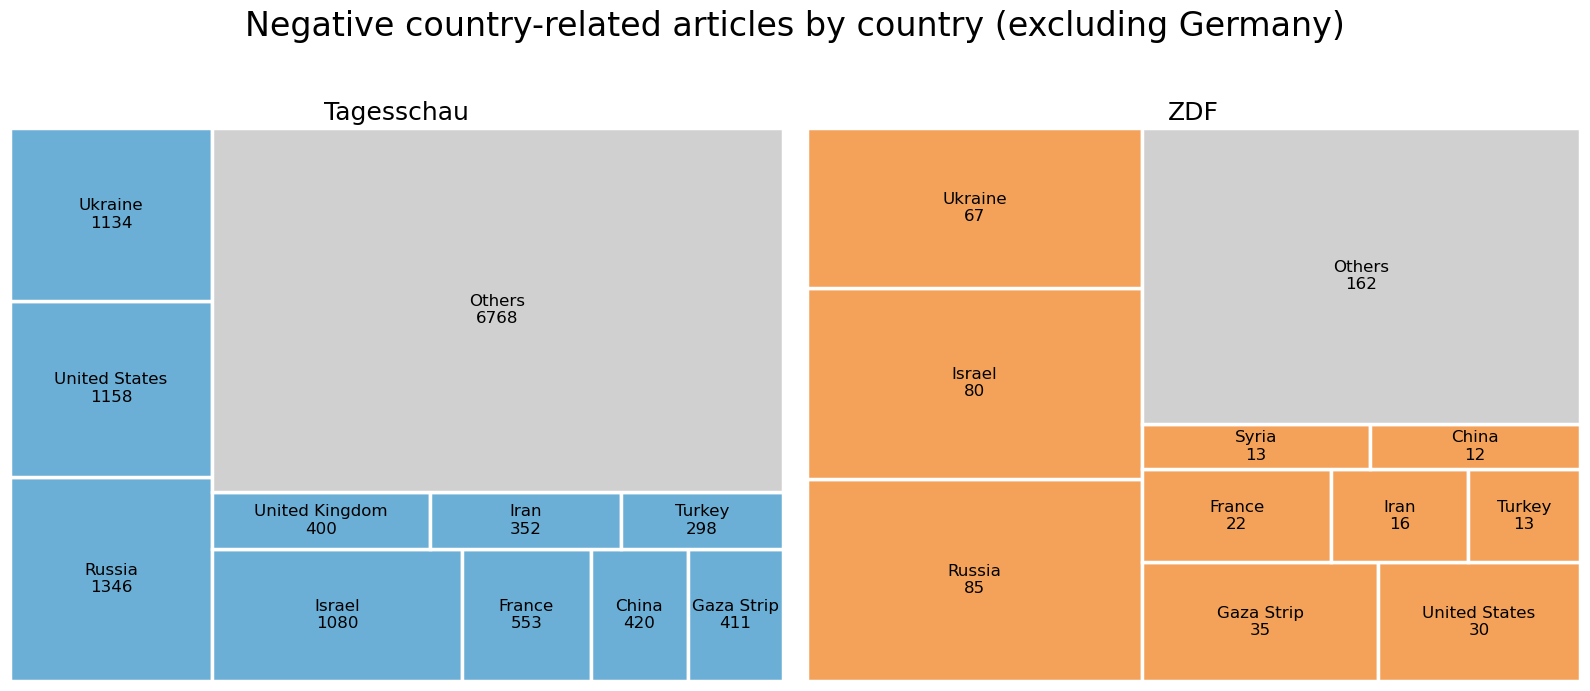

In [24]:
import squarify
q6 = df[df['SourceCommonName'].isin(['tagesschau.de', 'zdf.de'])].copy()
q6['outlet'] = q6['SourceCommonName'].replace({
    'tagesschau.de': 'Tagesschau',
    'zdf.de': 'ZDF'
})

def first_tone(x):
    try:
        return float(str(x).split(',')[0])
    except Exception:
        return np.nan

q6['tone'] = q6['V2Tone'].map(first_tone)

# extract first location name
def extract_first_location_name(loc_string):
    try:
        first_loc = str(loc_string).split(';')[0]
        parts = first_loc.split('#')
        if len(parts) > 1:
            return parts[1].strip()
        return np.nan
    except Exception:
        return np.nan

q6['location_name'] = q6['Locations'].apply(extract_first_location_name)

# convert location to country
def extract_country(location_name):
    if pd.isna(location_name):
        return np.nan
    location_name = str(location_name).strip()
    if ',' in location_name:
        return location_name.split(',')[-1].strip()
    return location_name

q6['country'] = q6['location_name'].apply(extract_country)

# remove missing tone/country
q6 = q6.dropna(subset=['tone', 'country'])

# remove broad/non-country labels
exclude_labels = {'World', 'Europe', 'Asia', 'Middle East', 'European Union'}
q6 = q6[~q6['country'].isin(exclude_labels)].copy()

# keep only negative articles
q6_neg = q6[q6['tone'] < -1].copy()

# exclude Germany
q6_neg = q6_neg[q6_neg['country'] != 'Germany'].copy()

# count negative articles by country and outlet
counts = (
    q6_neg.groupby(['outlet', 'country'])
    .size()
    .reset_index(name='count')
)

def prepare_treemap_data(data, outlet_name, top_n=10):
    d = data[data['outlet'] == outlet_name].copy().sort_values('count', ascending=False)
    top = d.head(top_n).copy()
    rest = d.iloc[top_n:]['count'].sum()

    if rest > 0:
        top = pd.concat([
            top,
            pd.DataFrame({'outlet': [outlet_name], 'country': ['Others'], 'count': [rest]})
        ], ignore_index=True)

    return top

tag_data = prepare_treemap_data(counts, 'Tagesschau', top_n=10)
zdf_data = prepare_treemap_data(counts, 'ZDF', top_n=10)

def make_labels(data):
    return [f"{country}\n{count}" for country, count in zip(data['country'], data['count'])]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

tag_color = '#6BAED6'
zdf_color = '#F4A259'
others_color = '#D0D0D0'

for ax, data, title, base_color in zip(
    axes,
    [tag_data, zdf_data],
    ['Tagesschau', 'ZDF'],
    [tag_color, zdf_color]
):
    colors = [others_color if country == 'Others' else base_color for country in data['country']]

    squarify.plot(
        sizes=data['count'],
        label=make_labels(data),
        color=colors,
        alpha=1.0,
        ax=ax,
        bar_kwargs=dict(edgecolor='white', linewidth=2.5),
        text_kwargs=dict(fontsize=12, color='black')
    )

    ax.set_title(title, fontsize=18)
    ax.axis('off')

fig.suptitle(
    'Negative country-related articles by country (excluding Germany)',
    fontsize=24,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()